In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)

In [ ]:
df_sal = pd.read_csv(r"../data/processed/processed_sales_data.csv")
df_sal[:10]

,transaction_id,store_id,region,category,product_name,quantity,unit_price,total_amount,payment_mode,sale_date,sales_rep_id,discount_pct
0,TXN01134,unknown,North,Furniture,Bed Frame,30.0,222.69,6680.70,UPI,2024-08-09,REP007,12.0
1,TXN01159,STORE_002,West,Toys,Board Game,20.0,391.69,7833.80,Debit Card,2024-03-12,REP002,8.2
2,TXN01704,STORE_004,South,Sports,Dumbbells,19.0,1098.14,20864.66,Credit Card,2024-01-09,REP007,18.1
3,TXN00521,STORE_003,South,Groceries,Tea,17.0,378.37,6432.29,Debit Card,2024-08-29,REP020,10.3
4,TXN01645,STORE_001,East,Sports,Yoga Mat,34.0,212.11,7211.74,Net Banking,2024-12-06,REP006,22.2
5,TXN00949,STORE_004,Central,Groceries,Olive Oil,15.0,841.20,12618.00,Debit Card,2024-06-15,REP019,0.7
6,TXN00066,STORE_002,south,Clothing,Jeans,2.0,1244.56,2489.12,UPI,2024-12-08,REP004,16.9
7,TXN01885,STORE_004,South,TOYS,Action Figure,9.0,1453.41,13080.69,unknown,2024-03-11,REP012,0.6
8,TXN00747,STORE_003,North,GROCERIES,Coffee,41.0,1824.65,74810.65,Debit Card,2024-05-29,REP017,19.2
9,TXN01085,STORE_003,North,Electronics,Smartphone,18.0,1854.86,33387.48,Credit Card,2024-04-17,REP018,3.5


In [3]:
df_sal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  2000 non-null   object 
 1   store_id        2000 non-null   object 
 2   region          2000 non-null   object 
 3   category        2000 non-null   object 
 4   product_name    2000 non-null   object 
 5   quantity        2000 non-null   float64
 6   unit_price      2000 non-null   float64
 7   total_amount    2000 non-null   float64
 8   payment_mode    2000 non-null   object 
 9   sale_date       2000 non-null   object 
 10  sales_rep_id    2000 non-null   object 
 11  discount_pct    2000 non-null   float64
dtypes: float64(4), object(8)
memory usage: 187.6+ KB


In [ ]:
df_cus = pd.read_csv(r"../data/processed/processed_customer_data.csv")
df_cus[0:10]

,customer_id,full_name,email,phone,gender,date_of_birth,city,occupation,membership_tier,lifetime_value,total_orders,is_active,joined_date,last_purchase_date,preferred_category
0,CUST01100,Customer_1100,customer1100@gmail.com,+91-9042480121,Other,2001-05-04,Surat,Teacher,Gold,37700.71,56,False,2023-08-07,2024-07-29,Sports
1,CUST01694,Customer_1694,customer1694@gmail.com,+91-7298829927,Male,1983-01-12,Mumbai,Government Employee,Silver,34961.74,177,True,2020-08-23,2024-05-30,Sports
2,CUST00104,Customer_104,customer104@gmail.com,+91-9507694884,Male,1986-06-19,none,Business Owner,Silver,35803.28,129,False,2021-09-29,2024-05-24,Electronics
3,CUST01532,Customer_1532,customer1532@gmail.com,+91-8485059977,Other,2001-05-14,Pune,Student,Platinum,35649.59,20,True,2019-09-02,NaN,Furniture
4,CUST01970,Customer_1970,customer1970@gmail.com,+91-7975175423,Female,1985-12-14,Jaipur,Student,Bronze,21719.53,89,True,2020-05-17,2024-06-27,Toys
5,CUST00802,Customer_802,customer802@gmail.com,+91-9548886614,Male,1969-10-05,Delhi,Teacher,Platinum,45186.68,116,False,2023-07-18,2024-10-12,Toys
6,CUST01431,Customer_1431,customer1431@yahoo.com,+91-8837782194,Male,2000-09-12,Bangalore,Teacher,Gold,8573.01,83,True,2019-07-10,2024-12-04,Toys
7,CUST00781,Customer_781,customer781@yahoo.com,+91-9681184477,Male,1993-06-24,Surat,Freelancer,Gold,10350.63,13,True,2021-10-12,2024-04-08,Toys
8,CUST01231,Customer_1231,customer1231@yahoo.com,+91-8408654725,Other,1995-12-03,Kolkata,Engineer,Silver,24147.76,154,True,2020-09-17,2024-12-25,Groceries
9,CUST01678,Customer_1678,customer1678@gmail.com,+91-9744517243,Other,2003-02-13,Hyderabad,Freelancer,Platinum,18134.28,89,True,2020-09-02,2024-09-17,Toys


## 1) What is the total revenue generated across all orders this period?

In [4]:
total_revenue = df_sal['total_amount'].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 51,873,368.60


In [5]:
df_sal['sale_date'] = pd.to_datetime(
    df_sal['sale_date'],
    errors='coerce'
)

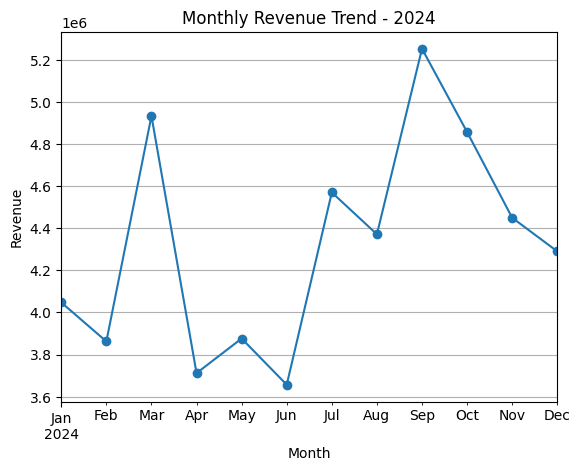

In [6]:
monthly_revenue = (
    df_sal
    .groupby(df_sal['sale_date'].dt.to_period('M'))['total_amount']
    .sum()
)

monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend - 2024')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

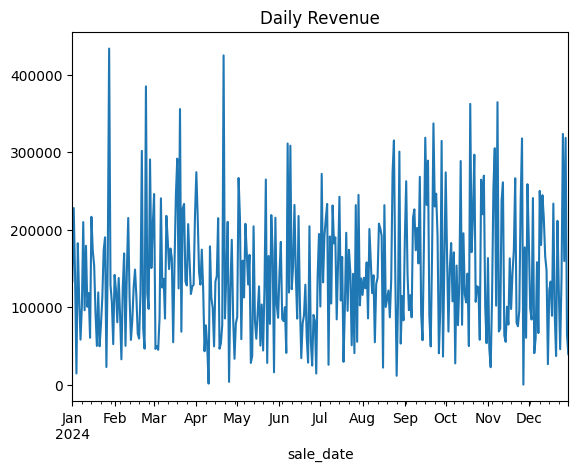

In [7]:
df_sal = df_sal.set_index('sale_date')
daily_revenue = df_sal['total_amount'].resample('D').sum()

daily_revenue.plot()
plt.title('Daily Revenue')
plt.show()

## 2) Which product category contributed the highest total revenue?2

In [8]:
category_revenue = (
    df_sal.groupby('category')['total_amount'].sum().sort_values(ascending=False)
)

category_revenue

category
Groceries      9067749.65
Toys           7861173.33
Furniture      7791433.08
Clothing       7477384.18
Sports         7374614.42
Electronics    7171495.97
GROCERIES      1210628.99
ELECTRONICS    1124247.88
SPORTS          960509.63
CLOTHING        874486.49
FURNITURE       558630.72
TOYS            401014.26
Name: total_amount, dtype: float64

In [9]:
top_category = category_revenue.idxmax()
top_revenue = category_revenue.max()

category_percent = (
    category_revenue / category_revenue.sum() * 100
)

print(f"Percentage Contributionn: {category_percent}")
print(f"Top Category: {top_category}")
print(f"Revenue: ₹{top_revenue:,.2f}")

Percentage Contributionn: category
Groceries      17.480549
Toys           15.154546
Furniture      15.020102
Clothing       14.414688
Sports         14.216571
Electronics    13.825005
GROCERIES       2.333816
ELECTRONICS     2.167293
SPORTS          1.851643
CLOTHING        1.685810
FURNITURE       1.076912
TOYS            0.773064
Name: total_amount, dtype: float64
Top Category: Groceries
Revenue: ₹9,067,749.65


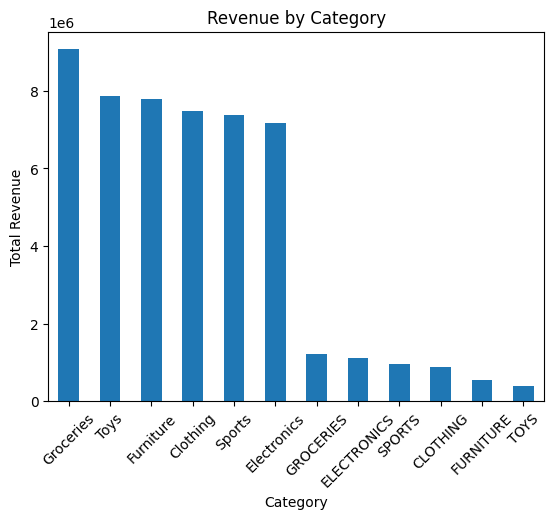

In [10]:
category_revenue.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## 3) Which product was ordered the most by total quantity sold?

In [14]:
df_sal.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

product_name
unknown       3298.0
Tea           2011.0
Bed Frame     2000.0
Coffee        1974.0
Jeans         1972.0
Lego Set      1856.0
Yoga Mat      1799.0
Dumbbells     1793.0
Olive Oil     1763.0
Remote Car    1672.0
Name: quantity, dtype: float64

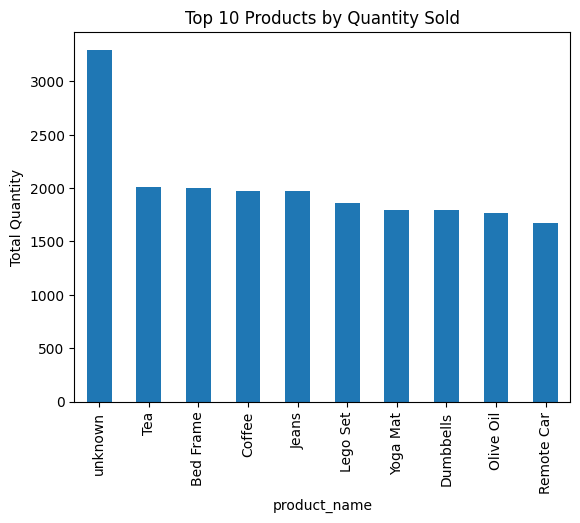

In [13]:
top_products = (df_sal.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10))

top_products.plot(kind='bar')
plt.title('Top 10 Products by Quantity Sold')
plt.ylabel('Total Quantity')
plt.show()

## 4) Which city placed the highest number of orders?

In [19]:
df_cus.groupby('city')['total_orders'].sum().sort_values(ascending = False)

city
Hyderabad    21468
Surat        20178
Ahmedabad    20087
Chennai      19807
Bangalore    19206
Mumbai       18802
Jaipur       18618
Delhi        18295
Kolkata      17021
Pune         16986
none         11629
Name: total_orders, dtype: int64

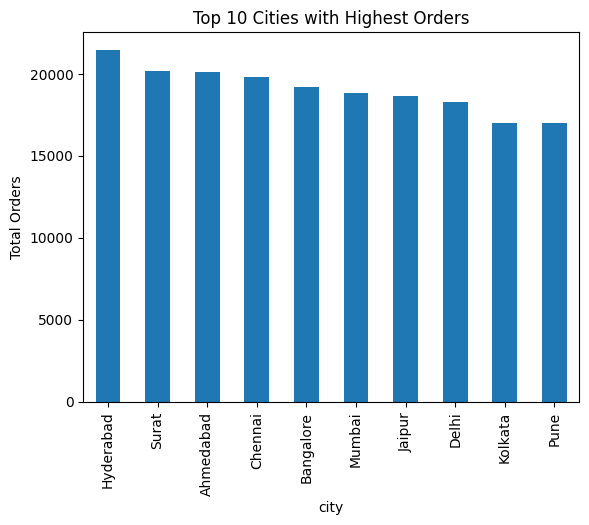

In [20]:
top_products = (df_cus.groupby('city')['total_orders'].sum().sort_values(ascending=False).head(10))

top_products.plot(kind='bar')
plt.title('Top 10 Cities with Highest Orders')
plt.ylabel('Total Orders')
plt.show()

## 5) How many orders had a quantity of zero after null-filling, and what percentage of total orders is that?

In [22]:
df_cus[df_cus['total_orders'] == 'unknown']

,customer_id,full_name,email,phone,gender,date_of_birth,city,occupation,membership_tier,lifetime_value,total_orders,is_active,joined_date,last_purchase_date,preferred_category


In [25]:
total_orders = len(df_cus)
zero_qty_orders = (df_sal['quantity'] == 'unknown').sum()
percentage = (zero_qty_orders / total_orders) * 100
print("Total Orders:", total_orders)
print("Orders with Quantity = 0:", zero_qty_orders)
print("Percentage of Total Orders: {:.2f}%".format(percentage))

Total Orders: 2000
Orders with Quantity = 0: 0
Percentage of Total Orders: 0.00%


## 6) What is the average order value (average total_revenue per order)?

In [32]:
total_orders = (df_cus['total_orders'].sum())
total_revenue = (df_cus['lifetime_value'].sum())
print("Total Orders:", total_orders)
print("Total Revenue:", total_revenue)

Total Orders: 202097
Total Revenue: 51301942.2


In [34]:
print(f"Average Order Value: {round(total_revenue/total_orders,2)}")

Average Order Value: 253.85
